In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

np.random.seed(43)

In [2]:
# --- Parametres ---
n     = 50         # nombre d'observations
p     = 32         # points sur la grille spatiale
N     = 3          # nombre de frequences
d     = 2*N + 1    # dimension de u
sigma = 0.3        # ecart-type du bruit
n_z   = 100        # points de quadrature pour l'integrale en z

xgrid = np.linspace(0, 2*np.pi, p,   endpoint=False)
zgrid = np.linspace(0, 2*np.pi, n_z, endpoint=False)
dz    = 2*np.pi / n_z

# Vrai parametre inconnu (a retrouver)
u_true = np.random.randn(d)

# Decalages Z_i uniformes
Z = np.random.uniform(0, 2*np.pi, n)

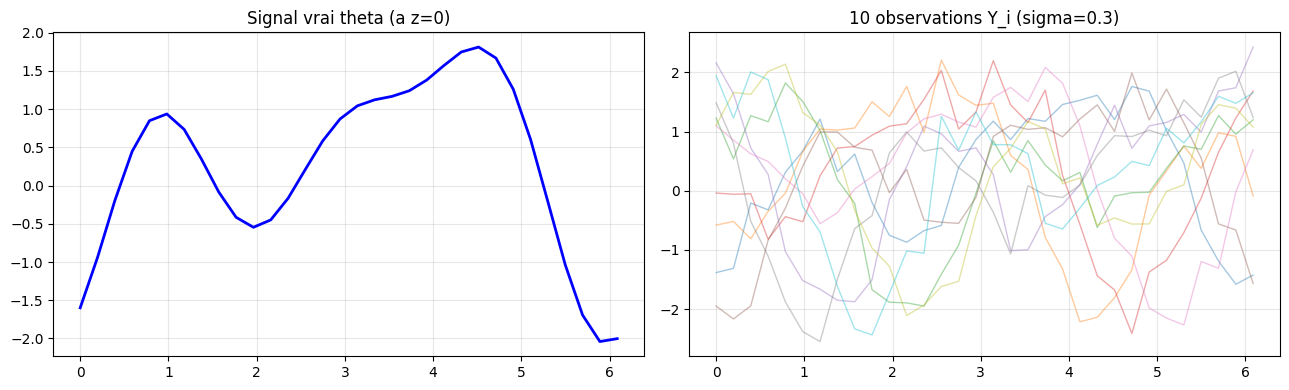

In [3]:
def build_phi(z):
    """
    Matrice Phi(z) de taille (p, d).
    Phi(z) @ u donne le signal theta_u evalue sur la grille, translate de z.
    """
    phi = np.zeros((p, d))
    phi[:, 0] = 1.0
    for k in range(1, N + 1):
        phi[:, 2*k - 1] = np.cos(k * (xgrid - z))
        phi[:, 2*k]     = np.sin(k * (xgrid - z))
    return phi  # (p, d)


def build_phiu(z, u):
    """Signal theta_u sur la grille, pour le decalage z. Retourne (p,)."""
    return build_phi(z) @ u


# --- Observations : Y_i = Phi(Z_i) u_true + sigma * bruit ---
signals      = np.array([build_phiu(z=zi, u=u_true) for zi in Z])  # (n, p)
observations = signals + sigma * np.random.randn(n, p)             # (n, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(xgrid, build_phiu(z=0, u=u_true), 'b-', lw=2)
ax1.set_title('Signal vrai theta (a z=0)'); ax1.grid(alpha=0.3)
for i in range(min(n, 10)):
    ax2.plot(xgrid, observations[i], alpha=0.4, lw=1)
ax2.set_title(f'{min(n,10)} observations Y_i (sigma={sigma})')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# Seuil de clipping : exp(-QI_MAX) est indiscernable de 0 en float64
QI_MAX = 745.0


def qi(z, y, u):
    """(1/2sigma^2) * ||y - Phi(z)u||^2, clippe a QI_MAX."""
    residual = y - build_phiu(z=z, u=u)              # (p,)
    sq_norm  = float(np.dot(residual, residual))
    return min(sq_norm / (2.0 * sigma**2), QI_MAX)


def log_likelihood(u):
    """
    Log-vraisemblance observee, approchee par quadrature :
        l_n(u) = C + sum_i log( dz * sum_q exp(-qi(z_q, yi, u)) ).
    Utilise logsumexp pour eviter les NaN.
    """
    C  = -0.5 * n * p * np.log(2*np.pi*sigma**2) - n * np.log(2*np.pi)
    ll = C
    for yi in observations:
        log_w = np.array([-qi(z=z, y=yi, u=u) for z in zgrid])  # (n_z,)
        ll += np.log(dz) + logsumexp(log_w)
    return ll

In [5]:
def e_step(u):
    """
    Calcule la matrice des poids a posteriori de forme (n, n_z).
        weights[i, q] = pi_i(z_q | u).
    """
    weights = np.zeros((n, n_z))

    for i, yi in enumerate(observations):
        # log w[i, q] = -qi(z_q, y_i, u)  (tous <= 0 grace au clipping)
        log_w = np.array([-qi(z=z, y=yi, u=u) for z in zgrid])  # (n_z,)

        # Stabilisation softmax
        m = log_w.max()
        w = np.exp(log_w - m)
        weights[i, :] = w / w.sum()

    return weights

In [6]:
def m_step(weights):
    """
    Moindres carres pondere, forme close : renvoie u^{k+1} = A^{-1} b.
        A = sum_{i, q} weights[i, q] * phi(z_q)^T @ phi(z_q)
        b = sum_{i, q} weights[i, q] * phi(z_q)^T @ y_i
    """
    A = np.zeros((d, d))
    b = np.zeros(d)

    for i, yi in enumerate(observations):
        for q, z in enumerate(zgrid):
            phi = build_phi(z)                          # (p, d)
            A  += weights[i, q] * (phi.T @ phi)         # (d, d)
            b  += weights[i, q] * (phi.T @ yi)          # (d,)

    return np.linalg.solve(A, b)

In [7]:
def em(u0, n_iter=100, tol=1e-6, verbose=True):
    """
    Algorithme EM a partir de u0. Renvoie :
        u_hat     : parametre final
        hist_ll   : historique de la log-vraisemblance
        hist_u    : historique des iteres u^{(k)}
    """
    u       = u0.copy()
    hist_ll = [log_likelihood(u)]
    hist_u  = [u.copy()]

    for k in range(n_iter):
        # --- E-step ---
        weights = e_step(u)

        # --- M-step ---
        u_new = m_step(weights)

        # --- Suivi ---
        ll_new = log_likelihood(u_new)
        hist_ll.append(ll_new)
        hist_u.append(u_new.copy())

        # Critere d'arret : gain de log-vraisemblance negligeable
        if abs(ll_new - hist_ll[-2]) < tol:
            if verbose:
                print(f'  Convergence a iter {k+1}  (gain={ll_new - hist_ll[-2]:.2e})')
            u = u_new
            break

        if verbose and (k + 1) % 10 == 0:
            print(f'  iter {k+1:3d} : ll={ll_new:8.2f}   ||du||={np.linalg.norm(u_new - u):.3e}')

        u = u_new

    return u, np.array(hist_ll), np.array(hist_u)

In [8]:
np.random.seed(123)
# Init de petite amplitude : evite que qi(z_q, yi, u0) sature a QI_MAX
# pour *tous* les z_q (ce qui rendrait les poids du 1er E-step uniformes
# et bloquerait EM sur un mauvais point fixe --- voir les remarques finales).
u0 = 0.5 * np.random.randn(d)

u_em, hist_ll, hist_u = em(u0, n_iter=80, tol=1e-6, verbose=True)

def translation_error(u_hat, u_true, xgrid):
    p = len(xgrid)
    sig_hat  = build_phiu(0, u_hat)
    sig_true = build_phiu(0, u_true)
    corr = np.fft.irfft(
        np.fft.rfft(sig_hat).conj() * np.fft.rfft(sig_true), n=p
    )
    best_shift = np.argmax(corr)
    sig_aligned = np.roll(sig_hat, best_shift)
    return np.linalg.norm(sig_aligned - sig_true) / np.linalg.norm(sig_true)

err_rel = translation_error(u_em, u_true, xgrid)

print()
print('u_em   =', np.round(u_em, 3))
print('u_true =', np.round(u_true, 3))
print(f'erreur relative : {err_rel:.4f}')

  iter  10 : ll= -510.80   ||du||=2.943e-03
  iter  20 : ll= -510.43   ||du||=1.307e-03
  iter  30 : ll= -510.37   ||du||=4.348e-04
  iter  40 : ll= -510.37   ||du||=1.380e-04
  iter  50 : ll= -510.37   ||du||=4.349e-05
  iter  60 : ll= -510.37   ||du||=1.368e-05
  Convergence a iter 62  (gain=9.89e-07)

u_em   = [ 0.263  0.872  0.451 -0.717  0.72   0.564 -0.336]
u_true = [ 0.257 -0.908 -0.379 -0.535  0.858 -0.413  0.498]
erreur relative : 0.1625


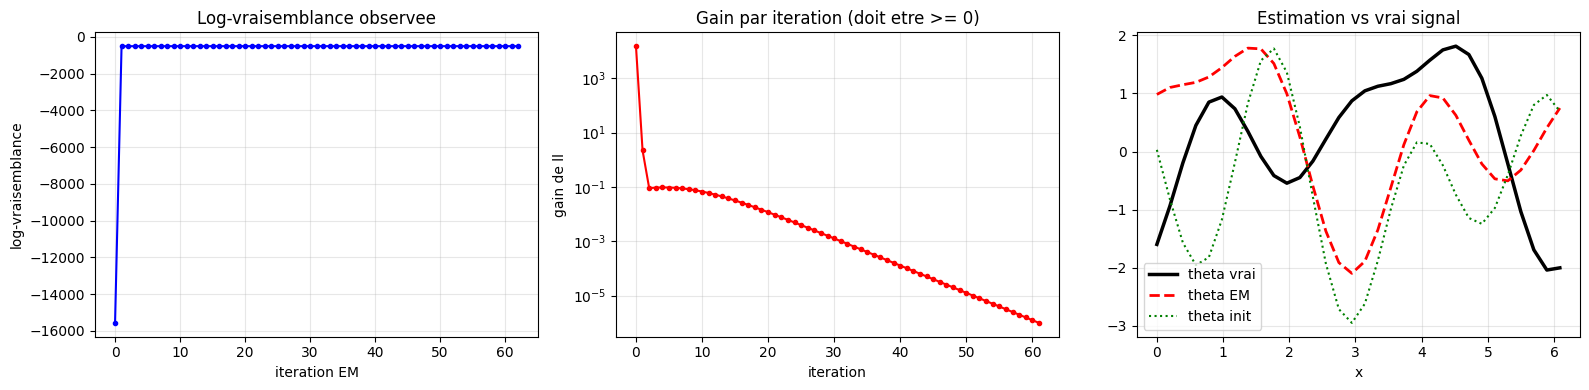

Gain minimum sur toutes les iterations : +9.894e-07
(doit etre positif aux erreurs numeriques pres : propriete d'EM)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Log-vraisemblance
axes[0].plot(hist_ll, 'b-o', ms=3)
axes[0].set_xlabel('iteration EM')
axes[0].set_ylabel('log-vraisemblance')
axes[0].set_title('Log-vraisemblance observee')
axes[0].grid(alpha=0.3)

# (b) Gain par iteration (doit rester >= 0 : propriete d'EM)
gains = np.diff(hist_ll)
axes[1].semilogy(np.maximum(gains, 1e-16), 'r-o', ms=3)
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('gain de ll')
axes[1].set_title('Gain par iteration (doit etre >= 0)')
axes[1].grid(alpha=0.3, which='both')

# (c) Signal vrai vs estime
theta_true_grid = build_phiu(z=0, u=u_true)
theta_em_grid   = build_phiu(z=0, u=u_em)
theta_init_grid = build_phiu(z=0, u=u0)
axes[2].plot(xgrid, theta_true_grid, 'k-',  lw=2.5, label='theta vrai')
axes[2].plot(xgrid, theta_em_grid,   'r--', lw=2,   label='theta EM')
axes[2].plot(xgrid, theta_init_grid, 'g:',  lw=1.5, label='theta init')
axes[2].set_xlabel('x')
axes[2].set_title('Estimation vs vrai signal')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Gain minimum sur toutes les iterations : {gains.min():+.3e}')
print('(doit etre positif aux erreurs numeriques pres : propriete d\'EM)')

start 0 : ll= -510.37   err_rel=0.0761   (60 iters)
start 1 : ll= -510.37   err_rel=0.1191   (59 iters)
start 2 : ll= -510.37   err_rel=0.0905   (55 iters)
start 3 : ll= -510.37   err_rel=0.1335   (47 iters)
start 4 : ll= -510.37   err_rel=0.1336   (53 iters)
start 5 : ll= -510.37   err_rel=0.1771   (77 iters)

Meilleur start : ll=-510.366   err_rel=0.1771


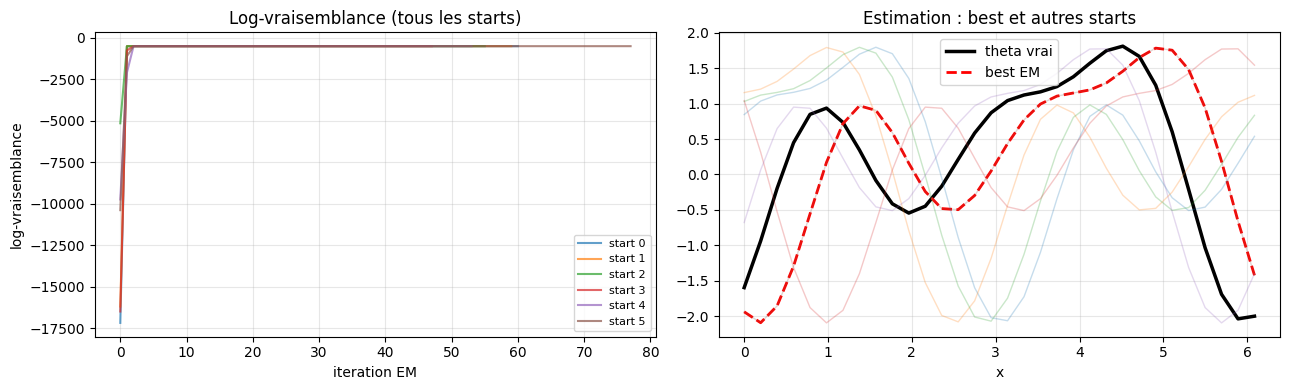

In [10]:
n_starts = 6
results  = []

for s in range(n_starts):
    np.random.seed(100 + s)
    u0 = 0.5 * np.random.randn(d)        # amplitude raisonnable (cf. remarques)

    u_hat, hist_ll, hist_u = em(u0, n_iter=80, verbose=False)
    err_rel = translation_error(u_hat, u_true, xgrid)
    results.append({
        'u_hat':   u_hat,
        'hist_ll': hist_ll,
        'll_final': hist_ll[-1],
        'err_rel': err_rel,
        'n_iter':  len(hist_ll) - 1,
    })
    print(f'start {s} : ll={hist_ll[-1]:8.2f}   err_rel={err_rel:.4f}   ({len(hist_ll)-1} iters)')

best = max(results, key=lambda r: r['ll_final'])
print(f'\nMeilleur start : ll={best["ll_final"]:.3f}   err_rel={best["err_rel"]:.4f}')

# Visualisation comparee des starts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for s, r in enumerate(results):
    axes[0].plot(r['hist_ll'], alpha=0.7, label=f'start {s}')
axes[0].set_xlabel('iteration EM'); axes[0].set_ylabel('log-vraisemblance')
axes[0].set_title('Log-vraisemblance (tous les starts)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(xgrid, build_phiu(z=0, u=u_true), 'k-', lw=2.5, label='theta vrai')
axes[1].plot(xgrid, build_phiu(z=0, u=best['u_hat']), 'r--', lw=2, label='best EM')
for r in results:
    axes[1].plot(xgrid, build_phiu(z=0, u=r['u_hat']), alpha=0.25, lw=1)
axes[1].set_xlabel('x'); axes[1].set_title('Estimation : best et autres starts')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()